# Lab 10 - Aprendizaje Semi-Supervisado
## Grupo 02: Co-Training
Idea central: uso de multiples vistas independientes del dataset 
Temas: 
- Supuesto de independencia condicional 
- Feature splitting 
- Algoritmos: Co-training con clasificadores distintos (ej. Naive Bayes + SVM) 

**Dataset:** Mushroom Classification (UCI / Kaggle)  
**Fuente:** https://www.kaggle.com/datasets/uciml/mushroom-classification  

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 2. Carga del Dataset

In [4]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "uciml/mushroom-classification",
    "mushrooms.csv",
)

print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

100%|██████████| 365k/365k [00:00<00:00, 1.02MB/s]

Dataset cargado: 8124 filas × 23 columnas


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 3. Descripción general del dataset

In [6]:

print('INFORMACIÓN GENERAL DEL DATASET')

print(f'  Filas    : {df.shape[0]:,}')
print(f'  Columnas : {df.shape[1]}')
print(f'  Variable objetivo: class (p = venenoso, e = comestible)')
print()
print('Tipos de datos:')
print(df.dtypes.value_counts())

INFORMACIÓN GENERAL DEL DATASET
  Filas    : 8,124
  Columnas : 23
  Variable objetivo: class (p = venenoso, e = comestible)

Tipos de datos:
str    23
Name: count, dtype: int64


In [7]:
# Descripción de columnas con sus valores únicos
descripcion = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores únicos': df.nunique(),
    'Valores nulos': df.isnull().sum(),
    '% nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Valores posibles': df.apply(lambda col: sorted(col.unique().tolist()))
})

print('\nResumen de columnas:')
descripcion


Resumen de columnas:


,Tipo,Valores únicos,Valores nulos,% nulos,Valores posibles
class,str,2,0,0.0,"[e, p]"
cap-shape,str,6,0,0.0,"[b, c, f, k, s, x]"
cap-surface,str,4,0,0.0,"[f, g, s, y]"
cap-color,str,10,0,0.0,"[b, c, e, g, n, p, r, u, w, y]"
bruises,str,2,0,0.0,"[f, t]"
odor,str,9,0,0.0,"[a, c, f, l, m, n, p, s, y]"
gill-attachment,str,2,0,0.0,"[a, f]"
gill-spacing,str,2,0,0.0,"[c, w]"
gill-size,str,2,0,0.0,"[b, n]"
gill-color,str,12,0,0.0,"[b, e, g, h, k, n, o, p, r, u, w, y]"


### 3.1 Estadísticas descriptivas


In [8]:
# Estadísticas descriptivas para variables categóricas
print('Estadísticas descriptivas (variables categóricas):')
df.describe(include='object')

Estadísticas descriptivas (variables categóricas):


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [9]:
# Moda por columna
modas = df.mode().iloc[0]
print('Moda (valor más frecuente) por columna:')
print(modas.to_frame(name='Moda').T)

Moda (valor más frecuente) por columna:
     class cap-shape cap-surface cap-color bruises odor gill-attachment  \
Moda     e         x           y         n       f    n               f   

     gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
Moda            c         b          b  ...                        s   

     stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
Moda                      w                      w         p          w   

     ring-number ring-type spore-print-color population habitat  
Moda           o         p                 w          v       d  

[1 rows x 23 columns]


## 4. Análisis de la variable objetivo: class

In [10]:
# Distribución de clases
class_counts = df['class'].value_counts()
class_labels = {'p': 'Venenoso (p)', 'e': 'Comestible (e)'}
class_counts.index = class_counts.index.map(class_labels)

print('Distribución de clases:')
print(class_counts.to_frame('Cantidad').assign(Porcentaje=lambda x: (x['Cantidad'] / len(df) * 100).round(2)))
print()
print(f'Balance de clases: {class_counts.min() / class_counts.max():.3f}  (1.0 = perfecto)')

Distribución de clases:
                Cantidad  Porcentaje
class                               
Comestible (e)      4208        51.8
Venenoso (p)        3916        48.2

Balance de clases: 0.931  (1.0 = perfecto)


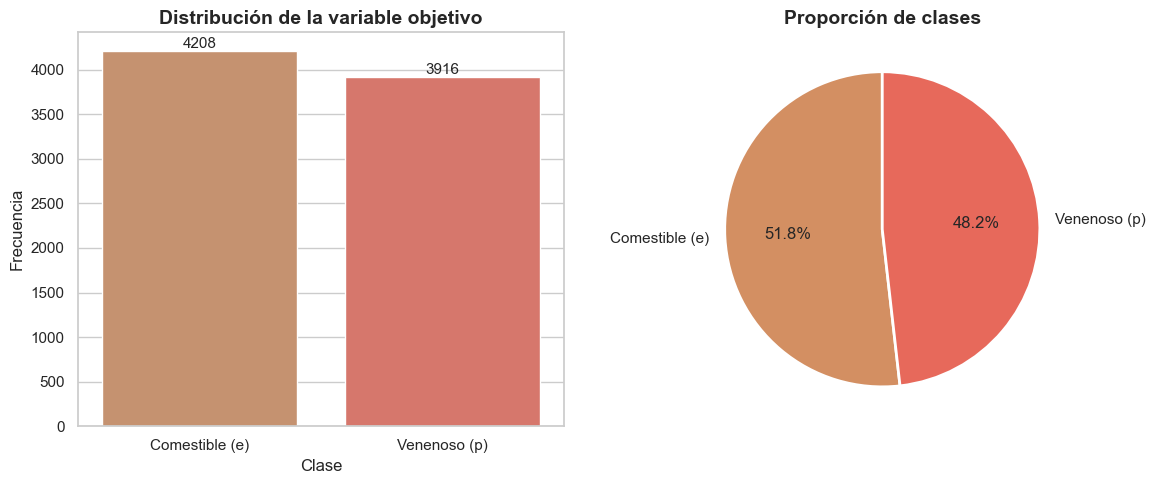

Figura 1. Distribución de la variable objetivo (class).


In [11]:
# Gráfico de distribución de clases — Seaborn + Plotly
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
sns.countplot(data=df, x='class', palette=["#d38f62", "#e7695b"],
              order=['e', 'p'], ax=axes[0])
axes[0].set_title('Distribución de la variable objetivo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticklabels(['Comestible (e)', 'Venenoso (p)'])
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height())}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=["#d38f62", "#e7695b"],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción de clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 1. Distribución de la variable objetivo (class).')

## 5. Distribución de variables categóricas

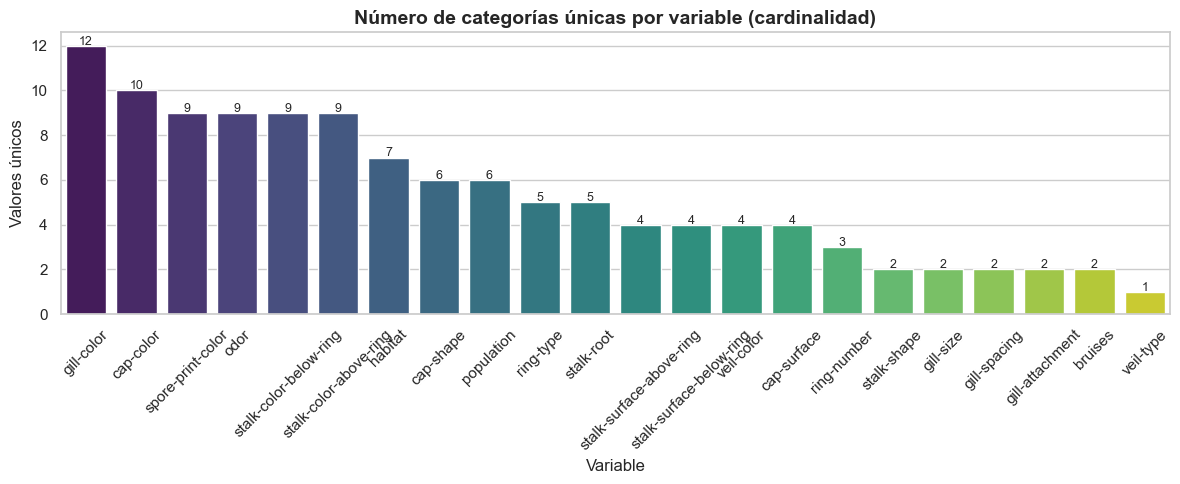

Figura 2. Cardinalidad (número de valores únicos) por variable.


In [12]:
# Frecuencia de cada categoría por variable — heatmap de cardinalidad
cardinalidad = df.nunique().sort_values(ascending=False).drop('class')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=cardinalidad.index, y=cardinalidad.values,
            palette='viridis', ax=ax)
ax.set_title('Número de categorías únicas por variable (cardinalidad)', fontsize=14, fontweight='bold')
ax.set_xlabel('Variable')
ax.set_ylabel('Valores únicos')
ax.tick_params(axis='x', rotation=45)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(int(bar.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('cardinalidad_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 2. Cardinalidad (número de valores únicos) por variable.')

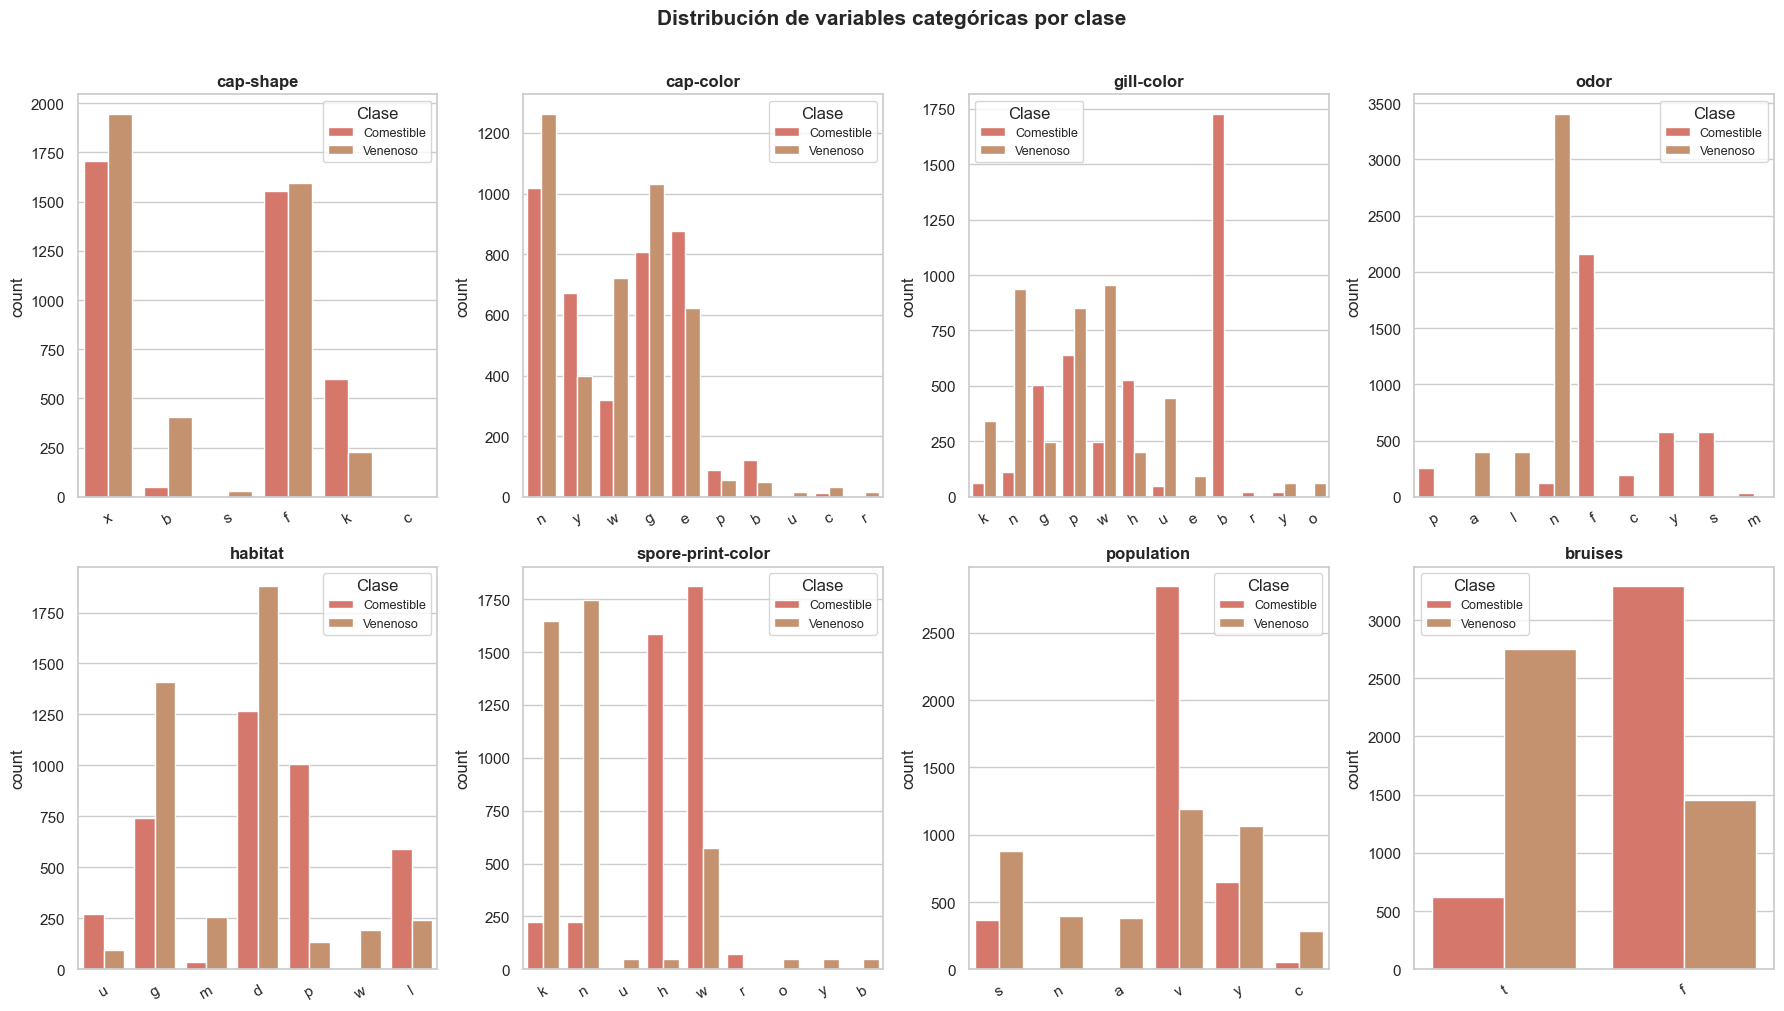

Figura 3. Distribución de 8 variables categóricas clave segmentadas por clase objetivo.


In [14]:
# Distribución de las primeras 8 variables más importantes vs clase objetivo — Seaborn
features_plot = ['cap-shape', 'cap-color', 'gill-color', 'odor',
                 'habitat', 'spore-print-color', 'population', 'bruises']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_plot):
    sns.countplot(data=df, x=col, hue='class',
                  palette={'e': '#d38f62', 'p': '#e7695b'}, 
                  ax=axes[i])
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Clase', labels=['Comestible', 'Venenoso'], fontsize=9)

plt.suptitle('Distribución de variables categóricas por clase', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribucion_variables_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 3. Distribución de 8 variables categóricas clave segmentadas por clase objetivo.')

## 6. Análisis de valores nulos y calidad del dato

In [15]:
# El dataset Mushroom tiene una columna especial: 'stalk-root' con '?' como missing
# Detectamos y reportamos esto

missing_explicit = (df == '?').sum()
missing_explicit = missing_explicit[missing_explicit > 0]

print('Valores nulos convencionales (NaN):', df.isnull().sum().sum())
print()
if len(missing_explicit) > 0:
    print('Columnas con "?" (missing implícito):')
    for col, count in missing_explicit.items():
        pct = count / len(df) * 100
        print(f'  {col}: {count} registros ({pct:.1f}%)')
else:
    print('No se encontraron valores "?" en el dataset.')

Valores nulos convencionales (NaN): 0

Columnas con "?" (missing implícito):
  stalk-root: 2480 registros (30.5%)


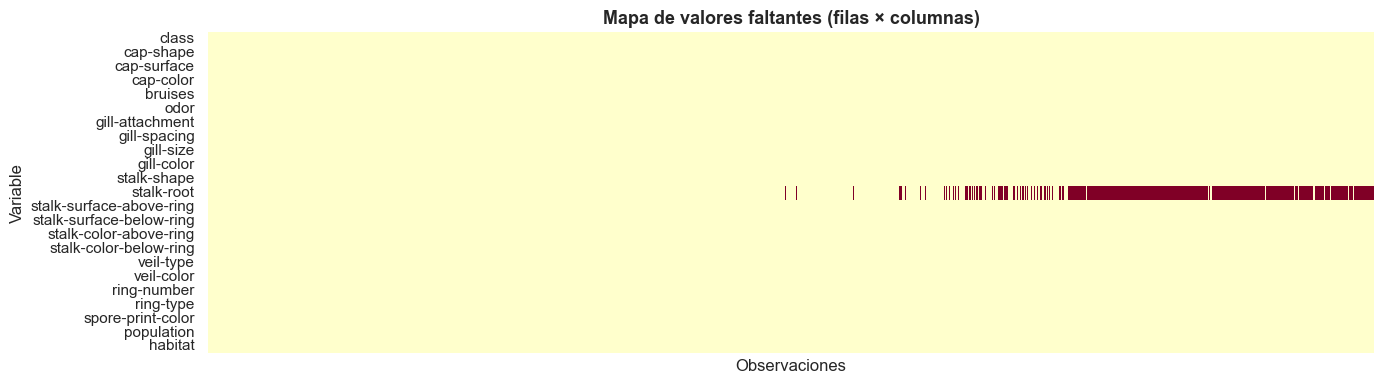

Figura 4. Mapa de valores faltantes. Amarillo/rojo indica ausencia de dato.


In [16]:
# Visualización de missing values con heatmap (Seaborn)
# Reemplazamos '?' por NaN para visualizar correctamente
df_viz = df.replace('?', np.nan)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df_viz.isnull().T,
            cmap='YlOrRd', cbar=False,
            yticklabels=True, xticklabels=False, ax=ax)
ax.set_title('Mapa de valores faltantes (filas × columnas)', fontsize=13, fontweight='bold')
ax.set_xlabel('Observaciones')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.savefig('missing_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 4. Mapa de valores faltantes. Amarillo/rojo indica ausencia de dato.')

## 7. Análisis de la variable odor — predictora clave

In [17]:
# 'odor' es conocida por ser altamente discriminativa en este dataset
odor_map = {
    'a': 'almendra', 'l': 'anís', 'c': 'creosota',
    'y': 'pescado', 'f': 'fétido', 'm': 'a tierra',
    'n': 'ninguno', 'p': 'picante', 's': 'a especias'
}

df_odor = df.copy()
df_odor['odor_label'] = df_odor['odor'].map(odor_map)

odor_class = df_odor.groupby(['odor_label', 'class']).size().unstack(fill_value=0)
odor_class.columns = ['Comestible', 'Venenoso']
odor_class = odor_class.sort_values('Venenoso', ascending=False)

fig = px.bar(
    odor_class.reset_index(), x='odor_label',
    y=['Comestible', 'Venenoso'],
    barmode='group',
    color_discrete_map={'Comestible': '#d38f62', 'Venenoso': '#e7695b'},
    title='Distribución de clases según tipo de olor (odor)',
    labels={'odor_label': 'Olor', 'value': 'Frecuencia', 'variable': 'Clase'}
)
fig.update_layout(plot_bgcolor='white', title_font_size=15)
fig.show()
print('Figura 5. La variable odor es altamente discriminativa: olores como fétido, a especias y creosota son exclusivos de hongos venenosos.')

Figura 5. La variable odor es altamente discriminativa: olores como fétido, a especias y creosota son exclusivos de hongos venenosos.
